# Preparação de dados

#### Carregar bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
from IPython.display import Markdown
from sklearn.datasets import load_digits

#### Carregar conjunto de dados

In [2]:
# Pinguins
df_penguins = sns.load_dataset('penguins')
display(Markdown("### Pinguins"))
# Adicionando dados faltantes (apenas para o exemplo)
missing_rate = .4
columns = ['island', 'body_mass_g']
for column in columns:
    missing_rows = np.random.choice(
        range(df_penguins.shape[0]),
        size=int(df_penguins.shape[0] * missing_rate),
        replace=False
    )
    df_penguins.loc[missing_rows, column] = np.NaN

## Gorjetas
display(df_penguins.head())

df_tips = sns.load_dataset('tips')
display(Markdown("### Tips"))
display(df_tips.head())

# Digits
digits = load_digits(as_frame=True)
df_digits = digits['frame']
display(Markdown("### Tips"))
display(df_digits.head())

### Pinguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,NaN,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,NaN,Female


### Tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Tips

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


## 2. Codificação de variáveis
#### Carregar bibliotecas

In [3]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

### 2.1. Nominal

In [4]:
df_penguins.species.unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [5]:
nominal_encoder = OneHotEncoder()
nominal_encoder.fit(df_penguins[['species']])
nominal_encoder.transform(df_penguins[['species']]).toarray()

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       ...,
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]])

### 2.2. Ordinal

In [6]:
df_tips.day.unique()

['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, object): ['Thur', 'Fri', 'Sat', 'Sun']

In [7]:
ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(df_tips[['day']])
ordinal_encoder.transform(df_tips[['day']])[:15]

array([[2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.]])

---

## 3. Tratamento de dados faltantes

#### Carregar bibliotecas

In [8]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

### 3.1. Deleção (usar o pandas)

In [9]:
display(Markdown("#### Quantidade faltante "))
display(df_penguins.isnull().sum())

display(Markdown("#### Quantidade de linhas e linhas"))
display(df_penguins.shape)

#### Quantidade faltante 

species                0
island               137
bill_length_mm         2
bill_depth_mm          2
flipper_length_mm      2
body_mass_g          139
sex                   11
dtype: int64

#### Quantidade de linhas e linhas

(344, 7)

#### 3.1.1. Linhas

In [10]:
df_penguins.dropna().shape

(119, 7)

#### 3.1.2. Colunas

In [11]:
df_penguins.dropna(axis=1).shape

(344, 1)

### 3.2. Imputação

In [12]:
df_penguins[['body_mass_g']]

,body_mass_g
0,3750.0
1,3800.0
2,3250.0
3,NaN
4,NaN
...,...
339,NaN
340,4850.0
341,5750.0
342,5200.0


#### 3.2.1. Estatísticas de tendência central

In [13]:
simple_imputer = SimpleImputer(strategy='mean')
simple_imputer.fit(df_penguins[['body_mass_g']])
simple_imputer.transform(df_penguins[['body_mass_g']])[:15]

array([[3750.        ],
       [3800.        ],
       [3250.        ],
       [4209.51219512],
       [4209.51219512],
       [3650.        ],
       [4209.51219512],
       [4675.        ],
       [3475.        ],
       [4250.        ],
       [3300.        ],
       [3700.        ],
       [3200.        ],
       [3800.        ],
       [4209.51219512]])

#### 3.2.2. Aprendizado de máquina

In [14]:
from sklearn.linear_model import LinearRegression
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import ExtraTreesRegressor
# from sklearn.neighbors import KNeighborsRegressor

iterative_imputer = IterativeImputer(estimator=LinearRegression())
iterative_imputer.fit_transform(df_penguins[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']])

array([[  39.1       ,   18.7       ,  181.        , 3750.        ],
       [  39.5       ,   17.4       ,  186.        , 3800.        ],
       [  40.3       ,   18.        ,  195.        , 3250.        ],
       ...,
       [  50.4       ,   15.7       ,  222.        , 5750.        ],
       [  45.2       ,   14.8       ,  212.        , 5200.        ],
       [  49.9       ,   16.1       ,  213.        , 4772.43649169]])

---

## 4. Tratamento de dados discrepantes

#### Gerar conjunto de dados artificial

,x1,x2
0,3.986857,1.446943
1,4.590754,8.092119
2,1.063387,1.063452
3,8.316851,5.069739
4,0.122102,4.170240


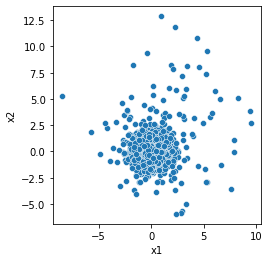

In [15]:
from numpy.random import RandomState

# reproducibility
r = RandomState(seed=42)

# simulating data
n_points = 1000
n_outliers = 100
df = pd.DataFrame(
    np.vstack([
        2+r.randn(n_outliers,2)*4,
        r.randn(n_points,2)
    ]), columns=['x1', 'x2']
)

display(df.head())
sns.scatterplot(x='x1', y='x2', data=df)
plt.gca().set_aspect('equal', 'box')
plt.show()

In [16]:
from sklearn.pipeline import TransformerMixin
from scipy.spatial.distance import cdist


class OutlierExtractor(TransformerMixin):
    def __init__(self, threshold=3, **kwargs):
        self.threshold = threshold
        self.kwargs = kwargs

    def transform(self, X, y=None):
        X = np.asarray(X)
        std = np.std(X)
        outliers_zscore = np.abs(cdist(X.mean(axis=0)[np.newaxis], X) / std)[0]
        if y:
            y = np.asarray(y)
            return (
                X[outliers_zscore >= self.threshold, :],
                y[outliers_zscore >= self.threshold, :]
            )
        return X[outliers_zscore >= self.threshold, :]
    def fit(self, *args, **kwargs):
        return self

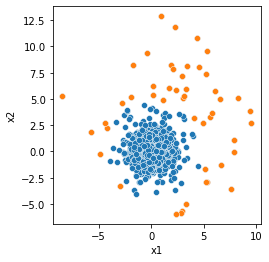

In [17]:
outlier_transform = OutlierExtractor(threshold=3)
outlier_transform.fit(df)
X_new = outlier_transform.transform(df)

sns.scatterplot(x='x1', y='x2', data=df)
sns.scatterplot(x=X_new[:, 0], y=X_new[:, 1])
plt.gca().set_aspect('equal', 'box')
plt.show()

## 5. Seleção de variáveis

#### Carregar bibliotecas


In [18]:
from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    chi2,
    SelectFromModel
)
from sklearn.linear_model import LogisticRegression

#### Conjunto de dados

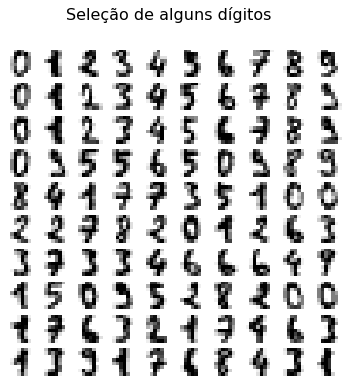

In [19]:
X, y = digits.data, digits.target
n_samples, n_features = X.shape
n_neighbors = 30
fig, axs = plt.subplots(nrows=10, ncols=10, figsize=(6, 6))
for idx, ax in enumerate(axs.ravel()):
    digits.images
    ax.imshow(digits.images[idx], cmap=plt.cm.binary)
    ax.axis("off")
_ = fig.suptitle("Seleção de alguns dígitos", fontsize=16)

### 5.1. Não supervisionados
#### 5.1.1. baixa variância

In [20]:
print("Conjunto original")
display(X.shape)

threshold_25 = np.quantile(X.std(), .25)

variance_selector = VarianceThreshold(threshold=threshold_25)
variance_selector.fit(X)
print("Conjunto transformado")
display(variance_selector.transform(X).shape)

Conjunto original


(1797, 64)

Conjunto transformado


(1797, 48)

### 5.2. Supervisionados

#### 5.2.1. Filtragem

In [21]:
print("Conjunto original")
display(X.shape)

kbest_selector = SelectKBest(score_func=chi2, k=30)
kbest_selector.fit(X, y)
print("Conjunto transformado")
display(kbest_selector.transform(X).shape)

Conjunto original


(1797, 64)

Conjunto transformado


(1797, 30)

#### 5.2.2. Embrulho

In [22]:
print("Conjunto original")
display(X.shape)

wraper_selector = SelectFromModel(estimator=LogisticRegression())
wraper_selector.fit(X, y)
print("Conjunto transformado")
display(wraper_selector.transform(X).shape)

Conjunto original


(1797, 64)

Conjunto transformado


(1797, 38)

## 6. Normalização
#### Carregar bibliotecas

In [23]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

#### Gerar conjunto de dados artificial

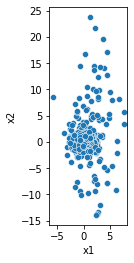

In [24]:
# reproducibility
r = RandomState(seed=42)

# simulating data
n_points = 1000
n_outliers = 100
df = pd.DataFrame(
    np.vstack([
        2+r.randn(n_outliers, 2)*[3, 8],
        r.randn(n_points-n_outliers, 2)
    ]), columns=['x1', 'x2']
)
old_df = df.copy()
df.head()

sns.scatterplot(x='x1', y='x2', data=df)
plt.gca().set_aspect('equal', 'box')
plt.show()

### 6.1. min-max

In [25]:
scaler_minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[:] = scaler_minmax.fit_transform(df_minmax)

### 6.2. z-score

In [26]:
scaler_zscore = StandardScaler()
df_zscore = df.copy()
df_zscore[:] = scaler_zscore.fit_transform(df_zscore)

### 6.3. Robusta

In [27]:
scaler_robust = RobustScaler()
df_robust = df.copy()
df_robust[:] = scaler_robust.fit_transform(df_robust)

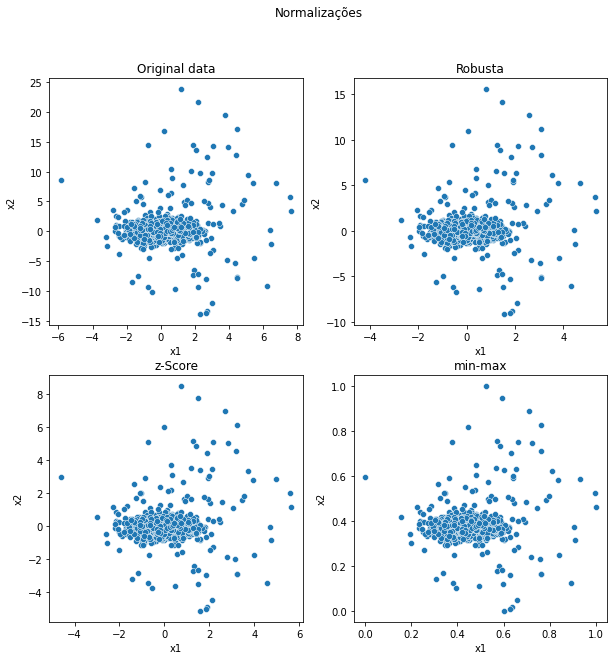

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(10,10))
fig.suptitle('Normalizações')
sns.scatterplot(x='x1', y='x2', data=old_df, ax=axes[0, 0])
axes[0, 0].set_title('Original data')
# axes[0, 0].set_aspect(1)

sns.scatterplot(x='x1', y='x2', data=df_minmax, ax=axes[1, 1])
axes[1, 1].set_title('min-max')
# axes[1, 1].set_aspect(1)

sns.scatterplot(x='x1', y='x2', data=df_zscore, ax=axes[1, 0])
axes[1, 0].set_title('z-Score')
# axes[1, 0].set_aspect(1)

sns.scatterplot(x='x1', y='x2', data=df_robust, ax=axes[0, 1])
axes[0, 1].set_title('Robusta')
# axes[0, 1].set_aspect(1)
plt.show()